# Multi-Layer Perceptron (MLP) — Attrition Prediction

## MLP Implementation (From Scratch)

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE


In [152]:
class Neuron:
    def __init__(self, input_dim, output_dim, activation=None):
        if isinstance(activation, ReLU):
            scale = np.sqrt(2.0 / input_dim) 
        else:
            scale = np.sqrt(1.0 / input_dim) 
        self.W = np.random.randn(input_dim, output_dim) * scale
        self.b = np.zeros((1, output_dim))  
        self.activation = activation

    def forward(self, X, training=True, dropout_rate=0.0):
        self.X = X
        self.Z = np.dot(X, self.W) + self.b
        if self.activation:
            self.A = self.activation.forward(self.Z)
        else:
            self.A = self.Z
        if training and dropout_rate > 0:
            self.dropout_mask = (np.random.rand(*self.A.shape) > dropout_rate) / (1 - dropout_rate)
            self.A *= self.dropout_mask
        else:
            self.dropout_mask = None
        return self.A

    def backward(self, dA): 
        if self.dropout_mask is not None:
            dA = dA * self.dropout_mask
        if self.activation:
            dZ = self.activation.backward(self.Z, dA)
        else:
            dZ = dA
        m = self.X.shape[0]  # number of samples
        dW = np.dot(self.X.T, dZ) / m
        db = np.sum(dZ, axis=0, keepdims=True) / m
        dX = np.dot(dZ, self.W.T)
        return dW, db, dX

class Model:
    def __init__(self, layers_dim, activations):
        self.layers = []
        input_dim = layers_dim[0]
        for output_dim, activation in zip(layers_dim[1:-1], activations[:-1]):
            self.layers.append(Neuron(input_dim, output_dim, activation=activation))
            input_dim = output_dim
        self.layers.append(Neuron(input_dim, layers_dim[-1], activation=activations[-1]))
        self.loss = []
        self.val_loss = []

    def predict(self, X):
        out = X
        for layer in self.layers:
            out = layer.forward(out, training=False, dropout_rate=0.0)
        return out

    def train(self, X, y, X_val=None, y_val=None, num_passes=20000, learning_rate=0.01,
              l2_lambda=0.01, dropout_rate=0.3, patience=500, print_loss=False):
        best_val_loss = float('inf')
        patience_counter = 0
        best_weights = None

        for epoch in range(num_passes):
            # Forward propagation (with dropout on hidden layers only)
            out = X
            for i, layer in enumerate(self.layers):
                # Apply dropout only to hidden layers 
                dr = dropout_rate if i < len(self.layers) - 1 else 0.0
                out = layer.forward(out, training=True, dropout_rate=dr)

            # Binary Cross-Entropy Loss + L2 Regularization
            eps = 1e-8 
            out_clipped = np.clip(out, eps, 1 - eps)
            bce_loss = -np.mean(y * np.log(out_clipped) + (1 - y) * np.log(1 - out_clipped))

            # L2 regularization term
            l2_penalty = 0
            for layer in self.layers:
                l2_penalty += np.sum(layer.W ** 2)
            l2_penalty *= l2_lambda / (2 * X.shape[0])

            loss = bce_loss + l2_penalty
            self.loss.append(loss)

            # BCE gradient
            dA = (out_clipped - y) / (out_clipped * (1 - out_clipped))

            # Back propagation with L2 regularization
            for layer in reversed(self.layers):
                dW, db, dA = layer.backward(dA)
                # Add L2 gradient
                dW += (l2_lambda / X.shape[0]) * layer.W
                # Gradient clipping to prevent exploding gradients
                dW = np.clip(dW, -5, 5)
                db = np.clip(db, -5, 5)
                layer.W -= learning_rate * dW
                layer.b -= learning_rate * db

            # Compute validation loss AFTER backprop (predict overwrites layer state)
            if X_val is not None and y_val is not None:
                val_out = self.predict(X_val)
                val_out_clipped = np.clip(val_out, eps, 1 - eps)
                val_loss = -np.mean(y_val * np.log(val_out_clipped) + (1 - y_val) * np.log(1 - val_out_clipped))
                self.val_loss.append(val_loss)

                # Early stopping check
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    # Save best weights
                    best_weights = [(layer.W.copy(), layer.b.copy()) for layer in self.layers]
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        if print_loss:
                            print(f"\nEarly stopping at epoch {epoch} (val_loss not improved for {patience} epochs)")
                        # Restore best weights
                        for layer, (W, b) in zip(self.layers, best_weights):
                            layer.W = W
                            layer.b = b
                        break

            if print_loss and epoch % 1000 == 0:
                # Calculate training accuracy
                pred = (out >= 0.5).astype(int)
                acc = np.mean(pred == y)
                val_info = ""
                if X_val is not None:
                    val_pred = (self.predict(X_val) >= 0.5).astype(int)
                    val_acc = np.mean(val_pred == y_val)
                    val_info = f" | Val Loss: {self.val_loss[-1]:.6f} | Val Acc: {val_acc:.4f}"
                print(f"Epoch {epoch:>5d} | Loss: {loss:.6f} | Train Acc: {acc:.4f}{val_info}")

# Activation functions
class ReLU:
    @staticmethod
    def forward(Z):
        return np.maximum(0, Z)

    @staticmethod
    def backward(Z, dA):
        return dA * (Z > 0)

class Sigmoid:
    @staticmethod
    def forward(Z):
        Z_clipped = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z_clipped))

    @staticmethod
    def backward(Z, dA):
        A = Sigmoid.forward(Z)
        return dA * A * (1 - A)

## Load & Prepare Data

In [153]:
# Load the RAW (non-SMOTE'd) dataset
df = pd.read_csv("../data/processed_data.csv")

# Convert Attrition values to binary (0 / 1)
attrition_vals = sorted(df["Attrition"].unique())
df["Attrition"] = df["Attrition"].map({attrition_vals[0]: 0, attrition_vals[1]: 1})

# Separate features and target
X = df.drop("Attrition", axis=1).values
y = df["Attrition"].values.reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

smote = SMOTE(random_state=42)
X_train, y_train_smote = smote.fit_resample(X_train, y_train.ravel())
y_train = y_train_smote.reshape(-1, 1)

print(f"Features: {X.shape[1]}")
print(f"Train after SMOTE : {X_train.shape[0]} samples (balanced)")
print(f"Validation        : {X_val.shape[0]} samples (real)")
print(f"Test              : {X_test.shape[0]} samples (real)")
print(f"Train attrition rate (balanced): {y_train.mean():.2%}")
print(f"Val   attrition rate (real):     {y_val.mean():.2%}")
print(f"Test  attrition rate (real):     {y_test.mean():.2%}")
print(df.head())


Features: 36
Train after SMOTE : 1724 samples (balanced)
Validation        : 220 samples (real)
Test              : 221 samples (real)
Train attrition rate (balanced): 50.00%
Val   attrition rate (real):     15.91%
Test  attrition rate (real):     16.29%
        Age  Attrition  BusinessTravel  Department  DistanceFromHome  \
0  0.448696          1        0.590048    1.401512         -1.013529   
1  1.323184          0       -0.913194   -0.493817         -0.152180   
2  0.011452          1        0.590048   -0.493817         -0.890479   
3 -0.425792          0       -0.913194   -0.493817         -0.767430   
4 -1.081659          0        0.590048   -0.493817         -0.890479   

   Education  EducationField  EnvironmentSatisfaction    Gender  \
0  -0.888082       -0.938496                -0.660531 -1.231716   
1  -1.863778       -0.938496                 0.254625  0.811876   
2  -0.888082        1.318192                 1.169781  0.811876   
3   1.063309       -0.938496                

## Train the Model

In [154]:
np.random.seed(42)

# Architecture: input -> 32 (ReLU) -> 16 (ReLU) -> 1 (Sigmoid)
model = Model(
    layers_dim=[X_train.shape[1], 32, 16, 1],
    activations=[ReLU(), ReLU(), Sigmoid()]
)

model.train(
    X_train, y_train,
    X_val=X_val, y_val=y_val, 
    num_passes=50000,
    learning_rate=0.01,
    l2_lambda=0.007,
    dropout_rate=0.35,
    patience=500,
    print_loss=True
)


Epoch     0 | Loss: 0.932040 | Train Acc: 0.5168 | Val Loss: 1.042976 | Val Acc: 0.2955
Epoch  1000 | Loss: 0.635439 | Train Acc: 0.6369 | Val Loss: 0.612754 | Val Acc: 0.6409
Epoch  2000 | Loss: 0.569075 | Train Acc: 0.7082 | Val Loss: 0.583298 | Val Acc: 0.6591
Epoch  3000 | Loss: 0.544476 | Train Acc: 0.7210 | Val Loss: 0.545146 | Val Acc: 0.6955
Epoch  4000 | Loss: 0.508146 | Train Acc: 0.7529 | Val Loss: 0.510416 | Val Acc: 0.7500
Epoch  5000 | Loss: 0.486207 | Train Acc: 0.7633 | Val Loss: 0.487306 | Val Acc: 0.7727
Epoch  6000 | Loss: 0.465451 | Train Acc: 0.7668 | Val Loss: 0.468852 | Val Acc: 0.7818
Epoch  7000 | Loss: 0.444052 | Train Acc: 0.7947 | Val Loss: 0.452975 | Val Acc: 0.7955
Epoch  8000 | Loss: 0.448992 | Train Acc: 0.7958 | Val Loss: 0.439441 | Val Acc: 0.8045
Epoch  9000 | Loss: 0.390334 | Train Acc: 0.8208 | Val Loss: 0.428492 | Val Acc: 0.8227
Epoch 10000 | Loss: 0.375169 | Train Acc: 0.8283 | Val Loss: 0.422176 | Val Acc: 0.8182
Epoch 11000 | Loss: 0.366604 | T

## Performance Curve

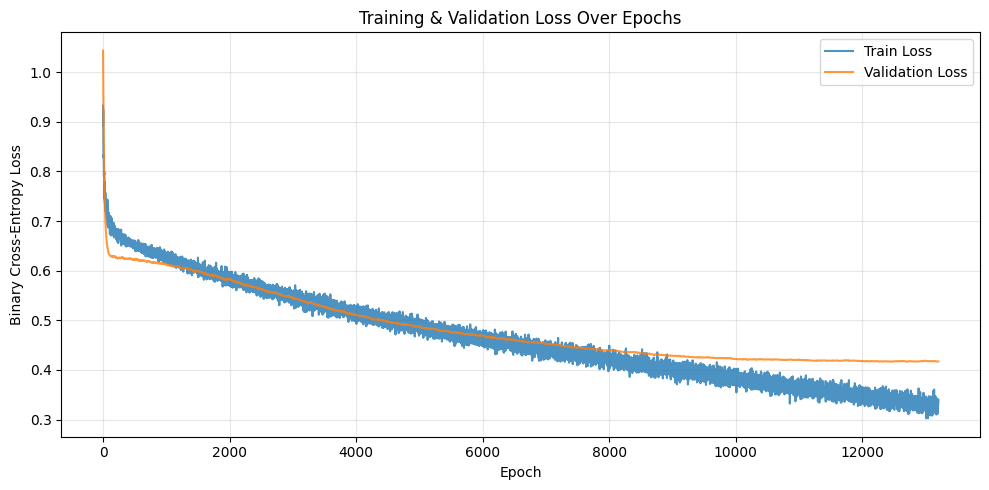

Stopped at epoch: 13200
Best validation loss: 0.416557


In [155]:
plt.figure(figsize=(10, 5))
plt.plot(model.loss, label="Train Loss", alpha=0.8)
if model.val_loss:
    plt.plot(model.val_loss, label="Validation Loss", alpha=0.8)
plt.title("Training & Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if model.val_loss:
    print(f"Stopped at epoch: {len(model.loss)}")
    print(f"Best validation loss: {min(model.val_loss):.6f}")

## Evaluation on Test Set

In [156]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Accauracy, Precision, Recall, F1 Score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred) 
f1 = f1_score(y_test, y_pred)

# Specificity (True Negative Rate)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("=" * 45)
print("       MLP — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}")
print(f"  Recall:      {recall:.4f}")
print(f"  Specificity: {specificity:.4f}")
print(f"  F1 Score:    {f1:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Attrition", "Attrition"]))

       MLP — Evaluation Results
  Accuracy:    0.7828
  Precision:   0.3966
  Recall:      0.6389
  Specificity: 0.8108
  F1 Score:    0.4894

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.92      0.81      0.86       185
   Attrition       0.40      0.64      0.49        36

    accuracy                           0.78       221
   macro avg       0.66      0.72      0.68       221
weighted avg       0.83      0.78      0.80       221



## Confusion Matrix

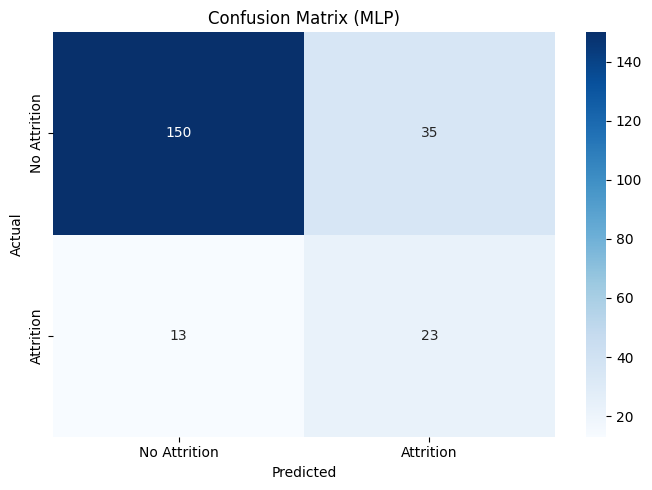

In [157]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve & AUC

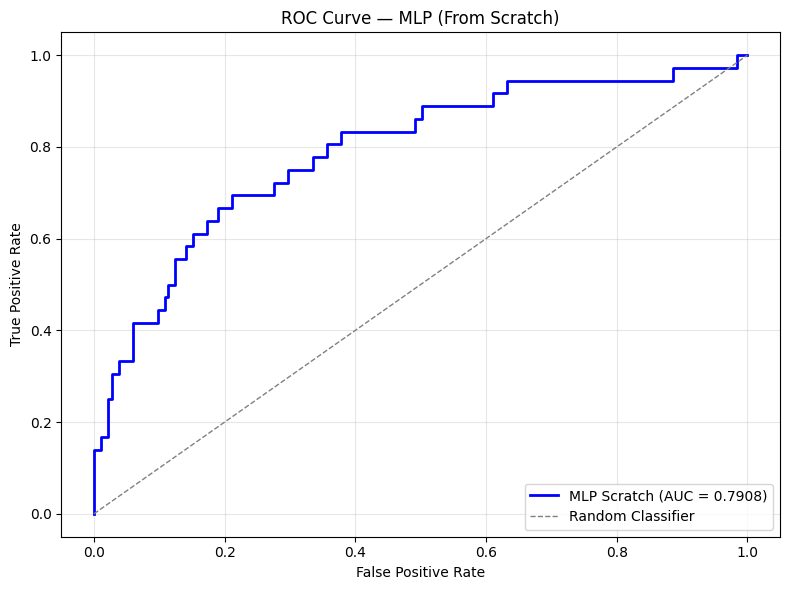

AUC Score: 0.7908


In [158]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'MLP Scratch (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MLP (From Scratch)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

---
# PyTorch MLP — Comparison

In [159]:
# Convert data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.FloatTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.FloatTensor(y_test)

class PyTorchMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.5):
        super(PyTorchMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

pytorch_mlp = PyTorchMLP(input_dim=X_train.shape[1], dropout_rate=0.5)
print(pytorch_mlp)
print(f"\nTotal parameters: {sum(p.numel() for p in pytorch_mlp.parameters()):,}")


PyTorchMLP(
  (network): Sequential(
    (0): Linear(in_features=36, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 1,729


## Train PyTorch MLP

In [160]:
torch.manual_seed(42)

criterion  = nn.BCELoss()
optimizer  = optim.Adam(pytorch_mlp.parameters(), lr=0.0005, weight_decay=5e-2)

pytorch_train_losses = []
pytorch_val_losses   = []
epochs           = 50000
patience         = 500
best_val_loss    = float('inf')
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    pytorch_mlp.train()
    y_pred = pytorch_mlp(X_train_t)
    loss   = criterion(y_pred, y_train_t)
    pytorch_train_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    pytorch_mlp.eval()
    with torch.no_grad():
        val_pred = pytorch_mlp(X_val_t)          
        val_loss = criterion(val_pred, y_val_t)
        pytorch_val_losses.append(val_loss.item())

    # Early stopping 
    if val_loss.item() < best_val_loss:
        best_val_loss    = val_loss.item()
        patience_counter = 0
        best_model_state = pytorch_mlp.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(val_loss not improved for {patience} epochs)")
            pytorch_mlp.load_state_dict(best_model_state)
            break

    if epoch % 1000 == 0:
        pytorch_mlp.eval()
        with torch.no_grad():
            pred    = (y_pred >= 0.5).float()
            acc     = (pred == y_train_t).float().mean()
            val_cls = (pytorch_mlp(X_val_t) >= 0.5).float()
            val_acc = (val_cls == y_val_t).float().mean()
        print(f"Epoch {epoch:>5d} | Loss: {loss.item():.6f} | Train Acc: {acc.item():.4f} "
              f"| Val Loss: {val_loss.item():.6f} | Val Acc: {val_acc.item():.4f}")


Epoch     0 | Loss: 0.698216 | Train Acc: 0.5006 | Val Loss: 0.718617 | Val Acc: 0.2273
Epoch  1000 | Loss: 0.479412 | Train Acc: 0.8155 | Val Loss: 0.487424 | Val Acc: 0.7636
Epoch  2000 | Loss: 0.460586 | Train Acc: 0.8341 | Val Loss: 0.475811 | Val Acc: 0.7818

Early stopping at epoch 2248 (val_loss not improved for 500 epochs)


## PyTorch MLP — Loss Curve

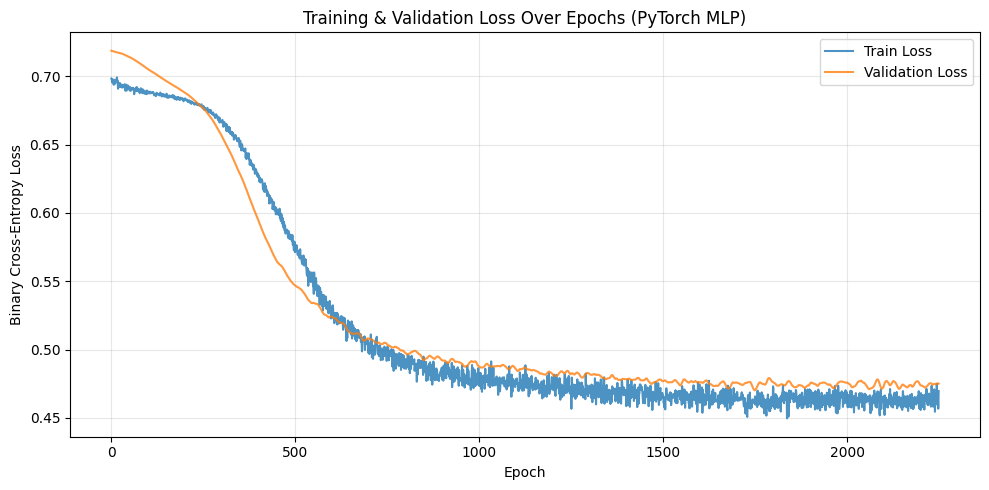

Stopped at epoch: 2249
Best validation loss: 0.470231


In [161]:
plt.figure(figsize=(10, 5))
plt.plot(pytorch_train_losses, label="Train Loss", alpha=0.8)
plt.plot(pytorch_val_losses, label="Validation Loss", alpha=0.8)
plt.title("Training & Validation Loss Over Epochs (PyTorch MLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Stopped at epoch: {len(pytorch_train_losses)}")
print(f"Best validation loss: {best_val_loss:.6f}")

## PyTorch MLP — Evaluation

In [162]:
pytorch_mlp.eval()
with torch.no_grad():
    y_pred_prob_pt = pytorch_mlp(X_test_t).numpy()
    y_pred_pt = (y_pred_prob_pt >= 0.5).astype(int)

accuracy_pt = accuracy_score(y_test, y_pred_pt)
precision_pt = precision_score(y_test, y_pred_pt)
recall_pt = recall_score(y_test, y_pred_pt)
f1_pt = f1_score(y_test, y_pred_pt)

cm_pt = confusion_matrix(y_test, y_pred_pt)
tn_pt, fp_pt, fn_pt, tp_pt = cm_pt.ravel()
specificity_pt = tn_pt / (tn_pt + fp_pt) if (tn_pt + fp_pt) > 0 else 0

print("=" * 45)
print("   PyTorch MLP — Evaluation Results")
print("=" * 45)
print(f"  Accuracy:    {accuracy_pt:.4f}")
print(f"  Precision:   {precision_pt:.4f}")
print(f"  Recall:      {recall_pt:.4f}")
print(f"  Specificity: {specificity_pt:.4f}")
print(f"  F1 Score:    {f1_pt:.4f}")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pt, target_names=["No Attrition", "Attrition"]))

   PyTorch MLP — Evaluation Results
  Accuracy:    0.7828
  Precision:   0.4000
  Recall:      0.6667
  Specificity: 0.8054
  F1 Score:    0.5000

Classification Report:
              precision    recall  f1-score   support

No Attrition       0.93      0.81      0.86       185
   Attrition       0.40      0.67      0.50        36

    accuracy                           0.78       221
   macro avg       0.66      0.74      0.68       221
weighted avg       0.84      0.78      0.80       221



## PyTorch MLP — Confusion Matrix

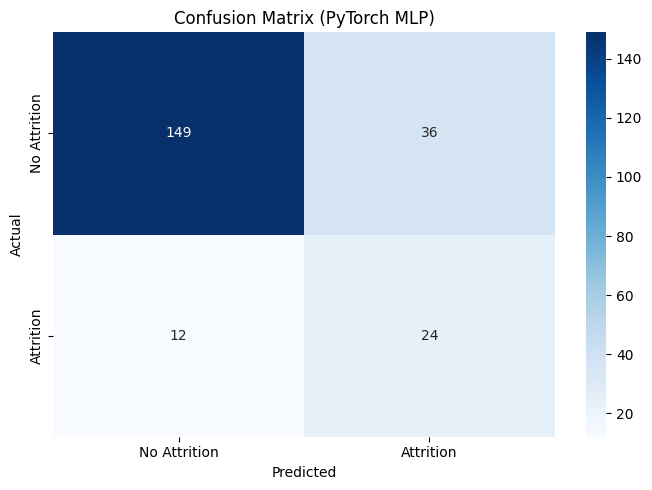

In [163]:
cm_pt = confusion_matrix(y_test, y_pred_pt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (PyTorch MLP)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## ROC Curve & AUC (PyTorch MLP)

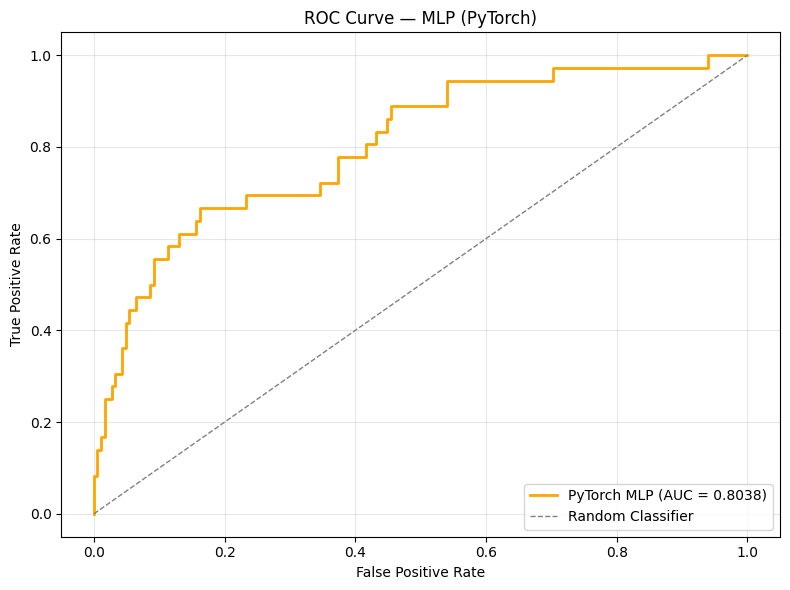

AUC Score (PyTorch): 0.8038


In [164]:
fpr_pt, tpr_pt, _ = roc_curve(y_test, y_pred_prob_pt)
roc_auc_pt = auc(fpr_pt, tpr_pt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_pt, tpr_pt, color='orange', lw=2, label=f'PyTorch MLP (AUC = {roc_auc_pt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MLP (PyTorch)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score (PyTorch): {roc_auc_pt:.4f}")

## MLP Comparison: From Scratch vs PyTorch

     MLP Comparison: From Scratch vs PyTorch
     Metric  MLP (Scratch)  MLP (PyTorch)
   Accuracy       0.782805       0.782805
  Precision       0.396552       0.400000
     Recall       0.638889       0.666667
Specificity       0.810811       0.805405
   F1 Score       0.489362       0.500000
        AUC       0.790841       0.803754


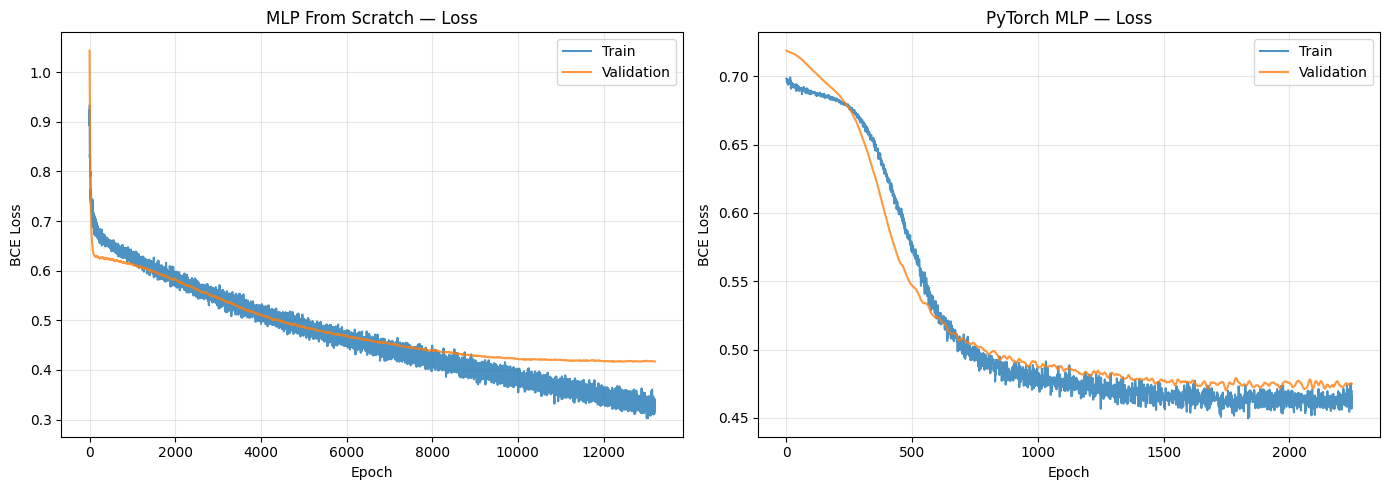

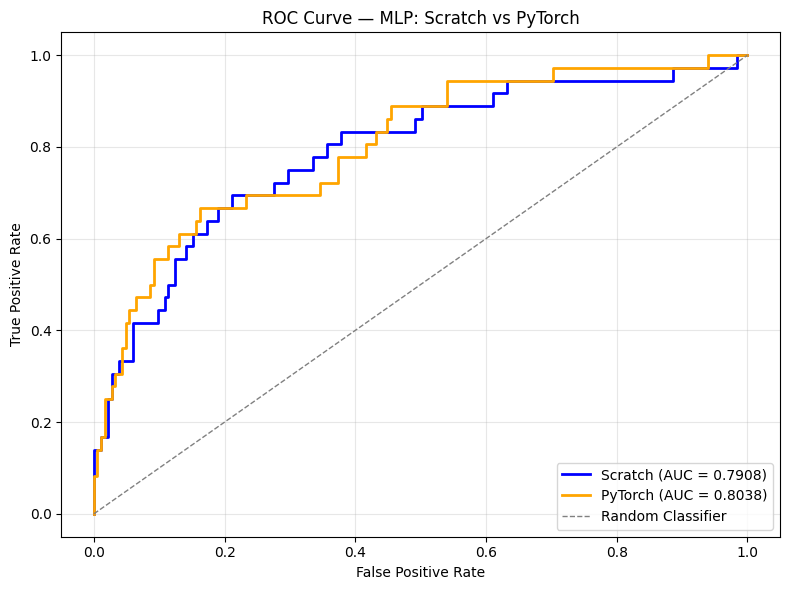

In [165]:
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "AUC"],
    "MLP (Scratch)": [accuracy, precision, recall, specificity, f1, roc_auc],
    "MLP (PyTorch)": [accuracy_pt, precision_pt, recall_pt, specificity_pt, f1_pt, roc_auc_pt]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 55)
print("     MLP Comparison: From Scratch vs PyTorch")
print("=" * 55)
print(comparison_df.to_string(index=False))
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model.loss, label="Train", alpha=0.8)
if model.val_loss:
    axes[0].plot(model.val_loss, label="Validation", alpha=0.8)
axes[0].set_title("MLP From Scratch — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(pytorch_train_losses, label="Train", alpha=0.8)
axes[1].plot(pytorch_val_losses, label="Validation", alpha=0.8)
axes[1].set_title("PyTorch MLP — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("BCE Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ROC Curve comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Scratch (AUC = {roc_auc:.4f})')
plt.plot(fpr_pt, tpr_pt, color='orange', lw=2, label=f'PyTorch (AUC = {roc_auc_pt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — MLP: Scratch vs PyTorch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()